In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm
from scipy.optimize import curve_fit, minimize
from radmc3dPy.analyze import *
from make_disk import generate_disk

Fast (Fortran90) Mie-scattering module could not be imported. Falling back to the slower Python version.


In [2]:
def read_from_dir(dir):
    os.chdir(dir)
    d = readData(dtemp=True, ddens=True, gdens=True, ispec='ch3oh')
    grid = readGrid(wgrid=False)
    os.chdir('..')
    return d, grid

In [3]:
def power_law(x, a, b, c):
    return a * x**b + c

In [4]:
def plot_profile(d, grid):
    nch3oh    = d.ndens_mol[:, :, 0, 0]
    dust      = np.sum(d.rhodust[:, :, 0, :], axis=2)
    t         = np.mean(d.dusttemp[:, :, 0, :], axis=2)
    R, Theta, Phi =  grid.x/au, grid.y, grid.z
    fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(18, 6),
                        subplot_kw={'projection': 'polar'})
    fig.subplots_adjust(left=0.05, right=0.95, top=0.9, bottom=0.1, wspace=0.3, hspace=0.05)
    cmaps = ['BuPu', 'OrRd', 'BuPu']
    titles = [r'$\rho_{dust}$', r'$T$', r'$n_{\mathregular{CH_3OH}}$']
    cbar = [r'log($\rho$) [g$cm^{-3}$]', r'log(T) [K]',r'log($n_{\mathregular{CH_3OH}}$) [$cm^{-3}$]']

    for idx_val, val in enumerate([dust, t, nch3oh]):
        c = ax[idx_val].pcolormesh(Theta-np.pi/2, R, np.log10(val), shading='auto', cmap=cmaps[idx_val])
        ax[idx_val].pcolormesh(Theta+np.pi/2, R, np.log10(val), shading='auto', cmap=cmaps[idx_val])
        if idx_val == 0:
            den = val
            # levels = np.linspace(np.log10(den).min(), np.log10(den).max(), 3)
            levels = [-20, -17, -14]
        ax[idx_val].contour(Theta-np.pi/2, R, np.log10(den), levels=levels, colors='k', linewidths=.7, linestyles='dashed')
        ax[idx_val].contour(Theta+np.pi/2, R, np.log10(den), levels=levels, colors='k', linewidths=.7, linestyles='dashed')
        ax[idx_val].set_xticks([])
        ax[idx_val].set_yticks([])
        fig.colorbar(c, ax=ax[idx_val], orientation='vertical', shrink=0.7).set_label(cbar[idx_val], fontsize=18)
        ax[idx_val].set_title(titles[idx_val], fontsize=26, color='k')


    scale_bar_ax = fig.add_axes([0.48, 0.12, 0.09, 0.02]) # [left, bottom, width, height]
    scale_bar = AnchoredSizeBar(scale_bar_ax.transData,
                                1,  # Size of the scale bar in data coordinates
                                f'{round(R[-1])} AU',  # Label for the scale bar
                                'lower center',  # Location
                                pad=0.1,
                                color='black',
                                frameon=False,
                                size_vertical=0.01,
                                fontproperties=fm.FontProperties(size=12))

    scale_bar_ax.add_artist(scale_bar)
    scale_bar_ax.set_axis_off()

    scale_bar_ax = fig.add_axes([0.15, 0.12, 0.09, 0.02]) # [left, bottom, width, height]
    scale_bar = AnchoredSizeBar(scale_bar_ax.transData,
                                1,  # Size of the scale bar in data coordinates
                                f'{round(R[-1])} AU',  # Label for the scale bar
                                'lower center',  # Location
                                pad=0.1,
                                color='black',
                                frameon=False,
                                size_vertical=0.01,
                                fontproperties=fm.FontProperties(size=12))

    scale_bar_ax.add_artist(scale_bar)
    scale_bar_ax.set_axis_off()

    scale_bar_ax = fig.add_axes([0.8, 0.12, 0.09, 0.02]) # [left, bottom, width, height]
    scale_bar = AnchoredSizeBar(scale_bar_ax.transData,
                                1,  # Size of the scale bar in data coordinates
                                f'{round(R[-1])} AU',  # Label for the scale bar
                                'lower center',  # Location
                                pad=0.1,
                                color='black',
                                frameon=False,
                                size_vertical=0.01,
                                fontproperties=fm.FontProperties(size=12))

    scale_bar_ax.add_artist(scale_bar)
    scale_bar_ax.set_axis_off()

# Compare midplane temperature between different heating mechanisms (accretion/irradiation/combine)

In [5]:
disk_acc  = generate_disk(heat='accretion'  , dir="disk_acc")
disk_irr  = generate_disk(heat='irradiation', dir="disk_irr")
disk_comb = generate_disk(heat='combine'    , dir="disk_comb") 

You have 24 Processors
You have 24 Processors
You have 24 Processors
Reading amr_grid.inp
Reading wavelength_micron.inp
Reading dust_temperature.dat


In [6]:
d_acc, grid = read_from_dir("./disk_acc/")
d_irr, _    = read_from_dir("./disk_irr/")
d_comb, _   = read_from_dir("./disk_comb/")

Reading amr_grid.inp
Reading wavelength_micron.inp
Reading dust_density.inp
Reading dust_temperature.dat
Reading gas density (numberdens_ch3oh.inp)
Reading amr_grid.inp
Reading amr_grid.inp
Reading wavelength_micron.inp
Reading dust_density.inp
Reading dust_temperature.dat
Reading gas density (numberdens_ch3oh.inp)
Reading amr_grid.inp
Reading amr_grid.inp
Reading wavelength_micron.inp
Reading dust_density.inp
Reading dust_temperature.dat
Reading gas density (numberdens_ch3oh.inp)
Reading amr_grid.inp


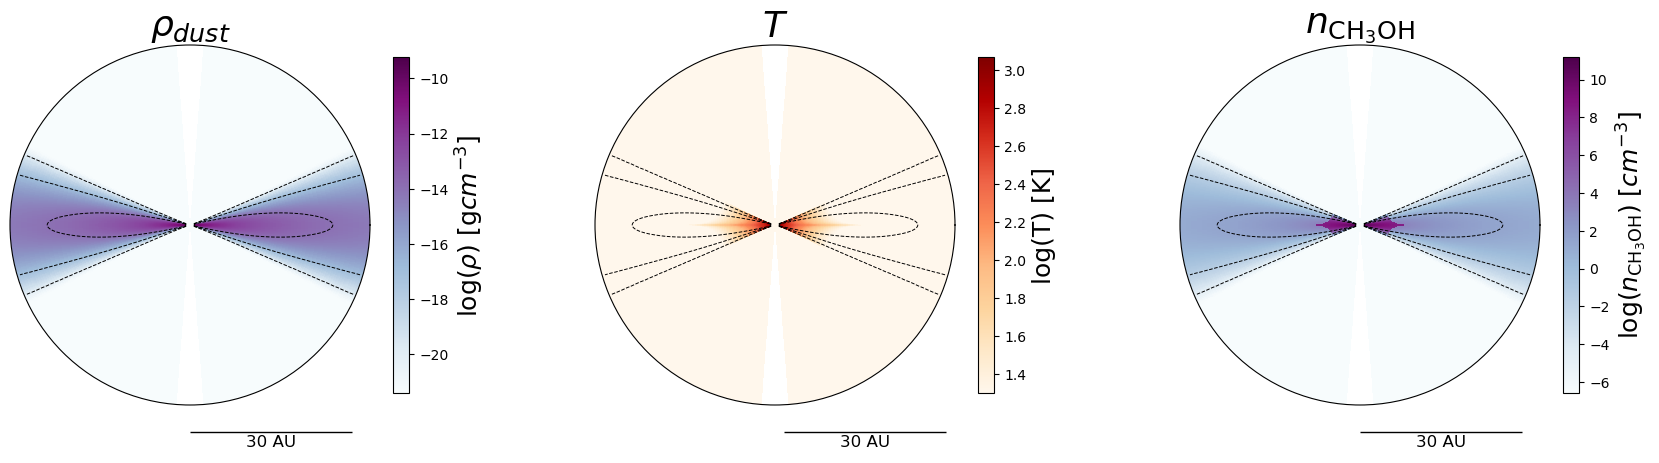

In [7]:
plot_profile(d_acc, grid)

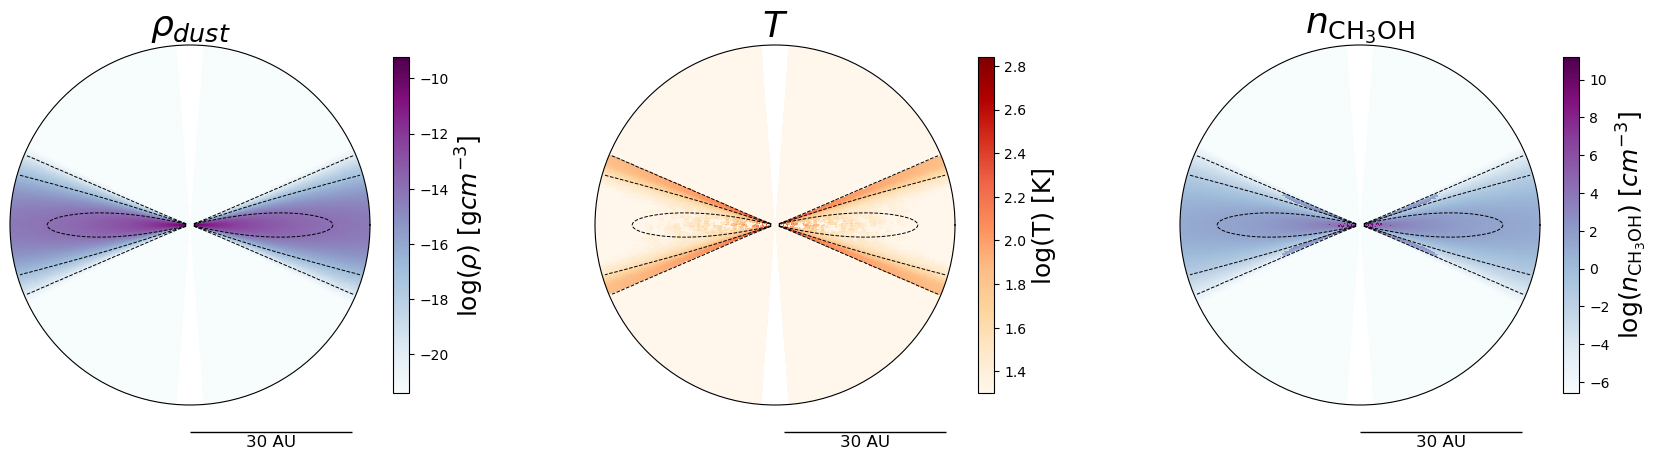

In [8]:
plot_profile(d_irr, grid)

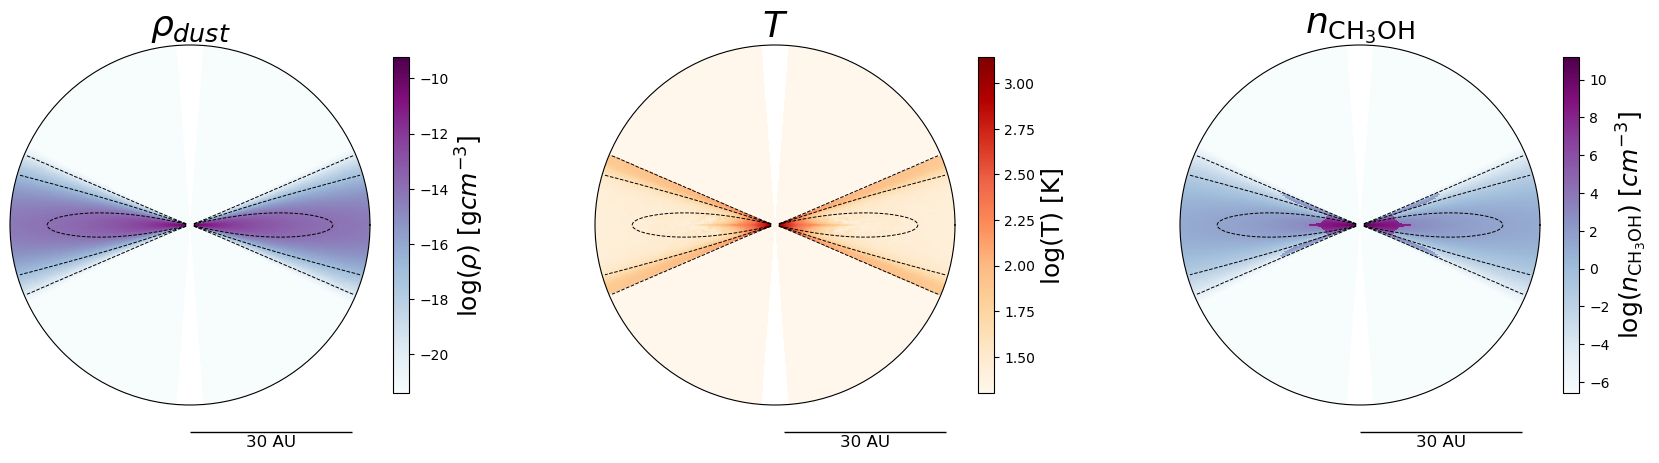

In [9]:
plot_profile(d_comb, grid)

In [10]:
r_grid = d_acc.grid.x/au
theta_grid = d_acc.grid.y

In [30]:
theta_slice = np.searchsorted(theta_grid, np.deg2rad(90))
print(theta_slice)
# print(np.rad2deg(theta_grid[130]))

199


(1, 30)

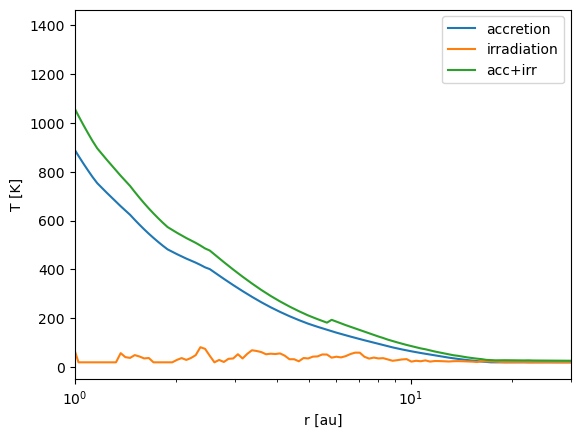

In [31]:
T_mid_acc = np.mean(d_acc.dusttemp[:, theta_slice, :, :], axis=(1,2))
T_mid_irr = np.mean(d_irr.dusttemp[:, theta_slice, :, :], axis=(1,2))
T_mid_comb = np.mean(d_comb.dusttemp[:, theta_slice, :, :], axis=(1,2))
plt.plot(r_grid, T_mid_acc, label='accretion')
plt.plot(r_grid, T_mid_irr, label='irradiation')
plt.plot(r_grid, T_mid_comb, label='acc+irr')
plt.legend()
plt.xlabel('r [au]')
plt.ylabel('T [K]')
# plt.yscale('log')
plt.xscale('log')
plt.xlim(left=1, right=30)

In [13]:
one_au = np.searchsorted(r_grid, 1)
print(one_au)

94


In [14]:
Sigma = disk_acc.DM.M*2

[ 5.37779064e+04 -1.81756771e+00 -2.18330898e+02]


Text(0, 0.5, 'surface density [g/cm^2]')

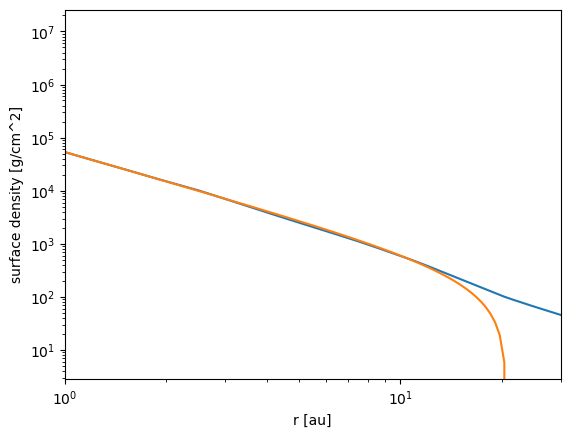

In [23]:
parms, _ = curve_fit(power_law, r_grid[one_au:], Sigma[one_au:], p0=[4e+4, -2, 1e0])
print(parms)
plt.plot(r_grid, Sigma)
plt.plot(r_grid, power_law(r_grid, *parms))
plt.yscale('log')
plt.xscale('log')
plt.xlim(left=1, right=30)
# plt.ylim(bottom=1e-16)
plt.xlabel('r [au]')
plt.ylabel('surface density [g/cm^2]')



[ 2.94879857e-10 -2.97443321e+00 -1.35021972e-13]


Text(0, 0.5, 'volume density [g/cm^3]')

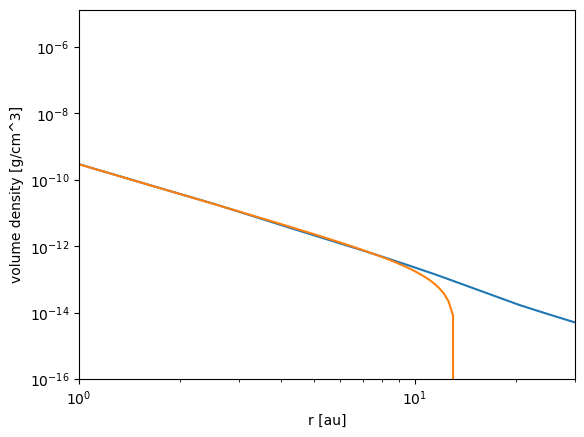

In [24]:
dust_dens = np.sum(d_acc.rhodust, axis=3)
rho_mid = np.mean(dust_dens[:, 199, :], axis=1)
parms, _ = curve_fit(power_law, r_grid[one_au:], rho_mid[one_au:], p0=[8e-10, -2, 1e-20])
print(parms)
plt.plot(r_grid, np.mean(dust_dens[:, 199, :], axis=1))
plt.plot(r_grid, power_law(r_grid, *parms))
plt.yscale('log')
plt.xscale('log')
plt.xlim(left=1, right=30)
plt.ylim(bottom=1e-16)
plt.xlabel('r [au]')
plt.ylabel('volume density [g/cm^3]')

